# Batch Analysis of AlphaFold Binder Predictions

This notebook demonstrates how to use the `pdb_align` API to automatically identify the bound chain in multimeric AlphaFold predictions and superimpose it onto a reference structure. We then analyze and cluster the predictions based on the 3D relative binding positions of the binders. We do NOT use a reference binder for comparison here. We are purely mapping where the predicted binders land in 3D space relative to the target protein.

In [1]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN

# Ensure our library is in path
sys.path.append("/home/dzyla/pdb_align")
from pdb_align.aligner import PDBAligner
from pdb_align.structure import StructureBase

# Prettify plots
sns.set_theme(style="whitegrid", context="notebook")

## 1. Batch Alignment with Binder-Aware Target Selection

We use `aligned_reference.cif` as the reference with **Chain A** being the core target protein.
For the predictions (`seed-*.cif`), they contain a stochastically assembled multimer (e.g. Chains A and B) and a binder (e.g. Chains H and L).
The new `align_with_binder` API automatically figures out whether the binder attached to chain A or chain B, sets that candidate as the target, and superimposes it onto the reference Chain A.

In [2]:
ref_file = "./../analysis_aligned/aligned_reference.cif"
mobile_files = glob.glob("./../analysis_aligned/seed-*.cif")
out_dir = "aligned_predictions"
os.makedirs(out_dir, exist_ok=True)

# Initialize aligner
aligner = PDBAligner(verbose=False)
aligner.set_reference(ref_file, chains=["A"])

results = []
print(f"Batch aligning {len(mobile_files)} multimeric predictions...")
for i, m_file in enumerate(mobile_files):
    aligner.add_mobile(m_file)
    try:
        # The API finds the candidate (A or B) closest to binders (H, L)
        # and calculates the alignment onto Reference chain A.
        res = aligner.align_with_binder(
            binder_chains=["H", "L"], 
            candidate_chains=["A", "B"], 
            mode="seq_guided", 
            atoms="CA"
        )
        out_path = os.path.join(out_dir, "aligned_" + os.path.basename(m_file))
        res.save_aligned_pdb(out_path)
        
        results.append({
            "filename": os.path.basename(m_file),
            "target_rmsd": res.rmsd,
            "target_tm_score": res.get_tm_score(),
            "out_path": out_path
        })
        if i % 10 == 0 and i > 0:
            print(f"  Processed {i}/{len(mobile_files)} files...")
    except Exception as e:
        print(f"Failed alignment for {m_file}: {e}")

df = pd.DataFrame(results)
print("Finished alignments and generated output CIFs.")

Batch aligning 60 multimeric predictions...
  Processed 10/60 files...
  Processed 20/60 files...
  Processed 30/60 files...
  Processed 40/60 files...
  Processed 50/60 files...
Finished alignments and generated output CIFs.


## 2. Evaluate Binder 3D Binding Modes

Now that all target predictions are rotationally and translationally superimposed onto the reference's frame of coordinates (Chain A), we can directly compare the physical locations of the predicted binders.

We calculate the 3D Center of Mass (COM) coordinates [X, Y, Z] of the predicted binders (`Chains H and L`) in the newly saved aligned structures. Grouping these 3D points reveals the main structural binding modes across the prediction seeds, **without requiring a reference binder.**

In [3]:
# Calculate 3D COM coordinates for each aligned binder
coms = []
for index, row in df.iterrows():
    try:
        mob_struct = StructureBase(row["out_path"], chains=["H", "L"])
        mob_hl_coords = mob_struct.get_coords(atoms="CA")
        mob_com = np.mean(mob_hl_coords, axis=0)
        coms.append(mob_com)
    except Exception as e:
        print(f"Warning: {row['filename']} -> {e}")
        coms.append([np.nan, np.nan, np.nan])

coms = np.array(coms)
df["com_x"] = coms[:, 0]
df["com_y"] = coms[:, 1]
df["com_z"] = coms[:, 2]
df = df.dropna()

print("Binder 3D coordinates extracted!")

Binder 3D coordinates extracted!


## 3. Statistical Clustering and Plotting

Using K-Means clustering on the 3D coordinate space, we group the predictions to automatically identify successful structures versus alternate conformations or failed predictions.

We will present the clusters on a 3D scatter plot of the binding space.

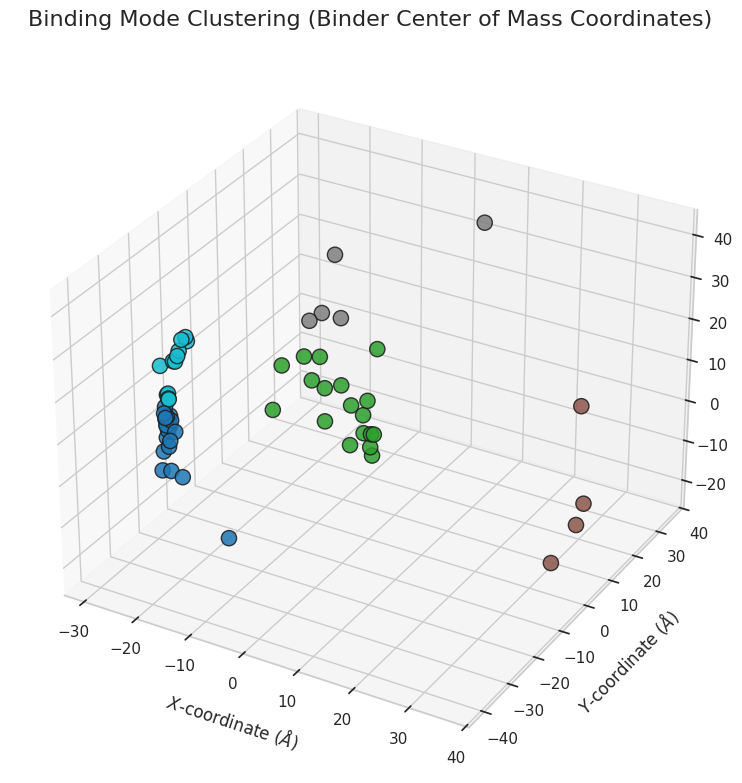

In [4]:
from collections import Counter

if len(df) > 0:
    # Cluster the 3D coordinates of the binder COMs
    # DBSCAN is often better than KMeans here, as it can separate noise points and doesn't require pre-specifying N clusters.
    # We'll use KMeans for simplicity unless DBScan fits better:
    features = df[["com_x", "com_y", "com_z"]]
    
    # Adjust n_clusters based on standard visual analysis of your dataset.
    kmeans = KMeans(n_clusters=5, random_state=42, n_init="auto")
    df["cluster"] = kmeans.fit_predict(features)
    
    # Create a 3D Scatter Plot to visualize the binding epitopes
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    scatter = ax.scatter(
        df["com_x"], 
        df["com_y"], 
        df["com_z"], 
        c=df["cluster"], 
        cmap="tab10", 
        s=120, 
        alpha=0.85, 
        edgecolor="k"
    )
    
    ax.set_title("Binding Mode Clustering (Binder Center of Mass Coordinates)", fontsize=16, pad=20)
    ax.set_xlabel(r"$X$-coordinate ($\AA$)", fontsize=12, labelpad=10)
    ax.set_ylabel(r"$Y$-coordinate ($\AA$)", fontsize=12, labelpad=10)
    ax.set_zlabel(r"$Z$-coordinate ($\AA$)", fontsize=12, labelpad=10)
    
    if scatter.legend_elements()[0]:
        legend = ax.legend(*scatter.legend_elements(), title="Cluster ID", bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.add_artist(legend)
    
    plt.tight_layout()
    plt.show()
else:
    print("No valid predictions available to cluster.")

We can also visualize the Target Core RMSD distribution per binding cluster to see which clusters represent higher-confidence models.

/tmp/ipykernel_178070/2405141169.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="cluster", y="target_rmsd", palette="tab10")


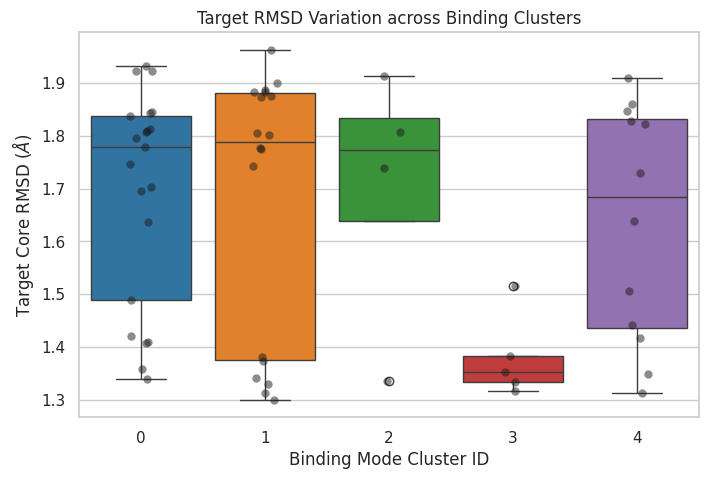

In [5]:
if len(df) > 0:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x="cluster", y="target_rmsd", palette="tab10")
    sns.stripplot(data=df, x="cluster", y="target_rmsd", color="k", alpha=0.5, size=6)
    plt.title("Target RMSD Variation across Binding Clusters")
    plt.xlabel("Binding Mode Cluster ID")
    plt.ylabel(r"Target Core RMSD ($\AA$)")
    plt.show()

In [6]:
if len(df) > 0:
    print("--- Summary of Binding Clusters ---")
    display(df.groupby("cluster").agg({
        "target_rmsd": ["mean", "std", "count"],
        "target_tm_score": ["mean"],
        "com_x": "mean",
        "com_y": "mean",
        "com_z": "mean"
    }).round(2))


--- Summary of Binding Clusters ---


target_rmsd             target_tm_score  com_x  com_y  com_z
               mean   std count            mean   mean   mean   mean
cluster                                                             
0              1.69  0.20    21            0.96 -23.41 -26.08   4.41
1              1.68  0.25    18            0.96  12.53 -34.55  30.80
2              1.70  0.25     4            0.94  32.63  11.08 -10.45
3              1.38  0.08     5            0.95 -17.89  31.35  12.18
4              1.64  0.22    12            0.94 -26.18 -19.56  16.95

In [1]:
from pdb_align.aligner import PDBAligner

# 1. Initialization
# =================
# Enable verbose logging to see step-by-step processing, matrix outputs, and reasoning.
aligner = PDBAligner(verbose=True)

# 2. Loading Structures and Chains
# ================================
# The API automatically handles remote fetching from the RCSB PDB or AlphaFold DB
aligner.add_reference("pdb:8UUP", chains=["A:10-150", "B"]) # Subdomain selection supported
aligner.add_mobile("af:P00533", chains=["A"])

# Need to update selected chains later? No problem:
aligner.set_reference_chains(["A"])
aligner.set_mobile_chains(["A"])

# 3. Alignment Execution
# ======================
# mode: "auto", "seq_guided", "seq_free_shape", "seq_free_window"
# atoms: "CA" (default), "backbone", or "all_heavy"
# Returns a state-free `AlignmentResult` object.
result = aligner.align(mode="auto", atoms="backbone", seq_gap_open=-10.0, seq_gap_extend=-0.5)

# 4. Accessing Data
# =================
print(f"RMSD: {result.rmsd}")                   # Properties evaluated dynamically
print(f"TM-Score: {result.tm_score}")

ref_coords, mob_coords = result.get_aligned_coords()
matched_pairs = result.get_matched_pairs()
rotation = result.rotation_matrix               # Rotation matrix (numpy)
translation = result.translation_vector         # Translation vector (numpy)

# 5. Sequence Alignments
# ======================
# Structure-based Sequence Alignment (based on 3D proximity):
seqA, seqB, score = result.get_structure_based_sequence_alignment()
result.print_sequence_alignment() # Prints formatted structure-based alignment

# Export structural alignment directly to FASTA:
result.save_sequence_alignment_fasta("alignment.fasta")

# General/Classic Sequence Alignment (pure 1D string matching between specified chains):
# Note: general alignment lives on the base aligner class since it is structure-independent
aligner.print_general_sequence_alignment(ref_chain="A", mob_chain="A")

# 6. Exploring Local Structural Deviations
# ========================================
# Report the highest C-alpha RMSD peaks ("on" specifies numbering format: 'reference' or 'mobile')
peaks = result.report_peaks(on="reference", top_n=5)

# Retrieve per-residue RMSD as a pandas DataFrame:
df = result.get_rmsd_df(on="reference")
# Or directly save it to CSV:
result.save_rmsd_csv("rmsd.csv", on="reference")

# Plot per-residue structural deviation (lines separated by chain hue)
# Supports publication-ready 'scientific' styling natively.
result.plot_rmsd("rmsd_plot.pdf", style="scientific", on="reference")

# 7. Batch Processing & Exports
# =============================
result.save_aligned_pdb("aligned_mobile.pdb")
result.save_log("alignment_log.txt") # Save formatted summary of run

# Generate a PyMOL or ChimeraX script that automatically loads both structures,
# applies the transformation, and visualizes the mobile chain colored by local RMSD.
result.save_pymol_script("visualization.pml", aligned_mobile_filename="aligned_mobile.pdb")
result.save_chimerax_script("visualization.cxc", aligned_mobile_filename="aligned_mobile.pdb")

# Batch process a whole directory across multiple cores natively
# Using the iterative generator allows tracking progress natively
for fname, res in aligner.batch_align_iter(mob_dir="/home/dzyla/analysis_aligned/", out_dir="out/", mode="auto", workers=4):
    print(f"Processed {fname} with TM-Score: {res.get('tm_score')}")

# Or get a pandas DataFrame immediately
df_batch = aligner.batch_align(mob_dir="/home/dzyla/", out_dir="out/", mode="auto", workers=4)

# And then calculate ensemble-wide metrics across all targets
stats = aligner.get_ensemble_statistics(df_batch)
print(stats) # Mean RMSD, Median TM-score, etc.

Reference set to: 8UUP.cif
  Chain A:10-150: 0 aa
  Chain B: 372 aa
Mobile set to: P00533.pdb
  Chain A: 1210 aa

Similarity Matrix:
  Chain A (ref) - Chain A (mobile): 3.3%
  Chain B (ref) - Chain A (mobile): 10.9%
  Chain C (ref) - Chain A (mobile): 3.3%
  Chain D (ref) - Chain A (mobile): 10.9%
  Chain E (ref) - Chain A (mobile): 3.3%
  Chain F (ref) - Chain A (mobile): 10.9%
Reference chains updated to: ['A']
Mobile chains updated to: ['A']

Alignment Completed:
  Mode evaluated: auto
  Sequence-based RMSD: 31.027 Å
  Sequence-free RMSD: 12.531 Å
  Chosen method: Sequence-free (window)
  Reason: Lower RMSD (12.53 Å) vs Sequence-guided (31.03 Å).
RMSD: 12.530777054873482
TM-Score: 0.11878338201979831
Pairwise Alignment:
                                                                                                                                                                                                                                                                           